# Sample analysis: `sample01_100k`

Sanity checks on the first snowball sample before any model training:
size, degree distribution, connectivity, hubs, and temporal coverage.

In [1]:
import json
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SAMPLE = Path("../data/samples/sample01_100k")
manifest = json.loads((SAMPLE / "manifest.json").read_text())
nodes = pd.read_parquet(SAMPLE / "nodes.parquet")
edges = pd.read_parquet(SAMPLE / "edges.parquet")
manifest

{'seed': '0xe5f40ae51b6d981e4a6539616bbff202c92f9eed',
 'max_nodes': 100000,
 'per_node_cap': 50,
 'rng_seed': 0,
 'n_nodes': 100000,
 'n_edges': 3624284,
 'created_at': '2026-07-31T21:08:23.190054+00:00',
 'duckdb_version': '1.5.5',
 'raw_manifest': {'row_count': 103344088,
  'window_start': '2026-05-01',
  'window_end': '2026-07-30'}}

In [2]:
print(f"{len(nodes):,} nodes, {len(edges):,} edges")
print(f"edges per node: {len(edges) / len(nodes):.1f}")
edges.head()

100,000 nodes, 3,624,284 edges
edges per node: 36.2


,from_address,to_address,block_timestamp,transaction_hash,value_eth
0,0xa090e606e30bd747d4e6245a1517ebe430f0057e,0xa9d1e08c7793af67e9d92fe308d5697fb81d3e43,2026-05-01 00:00:11+00:00,0x19042ab9f65ef49dc25f5e14787625feacad27ef2da4...,17.951701
1,0x88bbcaeeaf0dca4ad50e8aab9387cd78c60be758,0x28c6c06298d514db089934071355e5743bf21d60,2026-05-01 00:00:11+00:00,0xd51be92953ada7a1451ecf5998cb91fb75847321f185...,18.128477
2,0xac6725a932de2a23891844d69920844ce9e38bc2,0xefbae553e4ae604f18994a0158edabe54262f04f,2026-05-01 00:00:23+00:00,0x0ba591e16532f292f5e098161c0d6ff6e6cf2944b78d...,0.071366
3,0x21f8045b1a8c09eafe56085a33e58cfca217e904,0x67682d1190143c2e343e39b71704b9d3eb9cb6e4,2026-05-01 00:00:35+00:00,0x4198d91b6d387c4a3fb0e7795285695ff7eca8ca6156...,0.072000
4,0xcf72351a45d4a560f5e78ba3e1d00dd24602edae,0x0d0707963952f2fba59dd06f2b425ace40b492fe,2026-05-01 00:00:35+00:00,0x638135504d20af9866eff637060219d813e1f3264a0e...,12.264965


## Degree distribution

Transaction graphs are heavy-tailed: expect a rough power law, plus a
visible effect of the sampler's `per_node_cap` on BFS-traversed nodes.

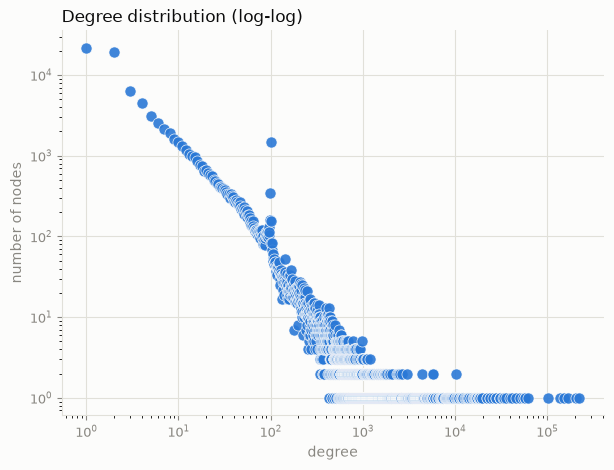

count    100000.000000
mean         72.485680
std        1491.596178
min           1.000000
25%           2.000000
50%           4.000000
75%          22.000000
max      223924.000000
dtype: float64

In [3]:
deg = pd.concat([
    edges.groupby("from_address").size(),
    edges.groupby("to_address").size(),
], axis=1).fillna(0).sum(axis=1).astype(int)

counts = deg.value_counts().sort_index()

# Chart style (dataviz skill): single series -> series-1 blue, no legend box;
# hairline recessive gridlines; muted axis ink; no top/right spines.
INK = "#0b0b0b"
MUTED = "#898781"
GRID = "#e1e0d9"
SERIES_1 = "#2a78d6"

fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor("#fcfcfb")
ax.set_facecolor("#fcfcfb")
ax.scatter(counts.index, counts.values, s=64, color=SERIES_1,
           edgecolors="#fcfcfb", linewidths=0.5, alpha=0.9)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("degree", color=MUTED)
ax.set_ylabel("number of nodes", color=MUTED)
ax.set_title("Degree distribution (log-log)", color=INK, fontsize=12, loc="left")
ax.grid(True, which="major", linewidth=0.8, color=GRID)
ax.set_axisbelow(True)
ax.tick_params(colors=MUTED, labelsize=9)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
for spine in ("left", "bottom"):
    ax.spines[spine].set_color(GRID)
plt.show()
deg.describe()

## Connectivity

The sample grew from one seed, so BFS-reached nodes are connected by
construction — but the *induced* graph can still contain nodes whose only
sampled edges were dropped by the cap. Count components on the undirected
graph.

In [4]:
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components

idx = {a: i for i, a in enumerate(nodes.address)}
r = edges.from_address.map(idx).to_numpy()
c = edges.to_address.map(idx).to_numpy()
n = len(nodes)
adj = coo_matrix((np.ones(len(r)), (r, c)), shape=(n, n))
n_comp, labels = connected_components(adj, directed=False)
sizes = np.bincount(labels)
print(f"{n_comp} components; largest = {sizes.max():,} nodes "
      f"({sizes.max() / n:.1%} of sample)")

1 components; largest = 100,000 nodes (100.0% of sample)


## Top hubs

The highest-degree nodes are usually exchanges/contracts. Worth eyeballing:
if one node dominates, consider a lower `per_node_cap` or hub exclusion in
the next sample.

In [5]:
deg.sort_values(ascending=False).head(10).rename("degree").to_frame()

,degree
0x4838b106fce9647bdf1e7877bf73ce8b0bad5f97,223924
0xb92fe925dc43a0ecde6c8b1a2709c170ec4fff4f,206757
0x396343362be2a4da1ce0c1c210945346fb82aa49,168720
0xbef7b36845ca31045e86d0b46dbcac4e6752a9ce,151623
0xdadb0d80178819f2319190d340ce9a924f783711,138721
0x388c818ca8b9251b393131c08a736a67ccb19297,101364
0x3e0a91dc5848e17765e3167249a2cb018cbb60ee,62049
0xae45a8240147e6179ec7c9f92c5a18f9a97b3fca,57464
0x22cb221cae98d6097082c80158b1472c45fed729,57110
0x66a9893cc07d91d95644aedd05d03f95e1dba8af,54240


## Temporal coverage

Link prediction needs edges spread across the window (we will split by
time later). Check edges per day.

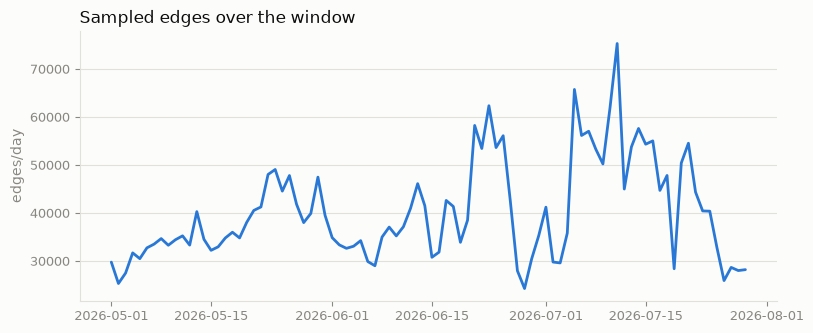

In [6]:
per_day = edges.set_index("block_timestamp").resample("1D").size()

fig, ax = plt.subplots(figsize=(9, 3.5))
fig.patch.set_facecolor("#fcfcfb")
ax.set_facecolor("#fcfcfb")
ax.plot(per_day.index, per_day.values, color=SERIES_1, linewidth=2,
        solid_capstyle="round", solid_joinstyle="round")
ax.set_ylabel("edges/day", color=MUTED)
ax.set_title("Sampled edges over the window", color=INK, fontsize=12, loc="left")
ax.grid(True, which="major", axis="y", linewidth=0.8, color=GRID)
ax.set_axisbelow(True)
ax.tick_params(colors=MUTED, labelsize=9)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
for spine in ("left", "bottom"):
    ax.spines[spine].set_color(GRID)
plt.show()

## Verdict

If the largest component holds most nodes, the degree distribution is
heavy-tailed but not one-node-dominated, and edges cover the whole window,
this sample is fit for building the link-prediction dataset (temporal
split + negative sampling) in the next phase.